# Pokemon VAE — Training Notebook

End-to-end training of a Variational Autoencoder on 96×96 RGBA Pokemon sprites.

**Before running:** populate the data splits from the project root:
```bash
python data/process_data.py
```

In [1]:
import csv
import os
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

## Configuration

In [2]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/gen_ai_image_project/"
os.chdir(drive_path)
!ls

Mounted at /content/drive
checkpoints	logs		   pokemon_distributions.json  scratch_space
checkpoints_v2	logs_v2		   pokemon_sprites
checkpoint_v2	model_scripts	   pokemon_sprites_old
data		model_train.ipynb  README.md


In [5]:
@dataclass
class VAEConfig:
    # Paths — relative to the project root (where this notebook lives)
    data_dir: str = drive_path + "data"
    checkpoint_dir: str = drive_path + "checkpoint_v2"
    log_dir: str = drive_path + "logs"

    # Image
    image_size: int = 96
    channels: int = 4           # RGBA

    # Model
    latent_dim: int = 128
    hidden_dim: int = 512
    beta: float = 1.0           # KL weight; 1.0 = standard VAE
    encoder_dropout: float = 0.3

    # LR scheduler (ReduceLROnPlateau)
    lr_patience: int = 15
    lr_factor: float = 0.5
    lr_min: float = 1e-6

    # Training
    batch_size: int = 64
    epochs: int = 200
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    num_workers: int = 4
    pin_memory: bool = True

    # Checkpointing
    save_every: int = 10
    resume_from: str = ""       # set to a .pt path to resume training

    # Logging
    log_interval: int = 50      # print loss every N batches

cfg = VAEConfig()



In [6]:

cfg.resume_from = "/content/drive/MyDrive/gen_ai_image_project/checkpoint_v2/vae_epoch_0400.pt"
cfg.learning_rate = 1e-4   # start lower since we're resuming
cfg.epochs = 400

## Dataset

In [7]:
def get_transforms(image_size: int, augment: bool = False) -> transforms.Compose:
    ops = []
    if augment:
        ops.append(transforms.RandomHorizontalFlip())
    ops += [
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),  # scales uint8 → float [0, 1]
    ]
    return transforms.Compose(ops)


class PokemonDataset(Dataset):
    def __init__(self, data_dir: str, image_size: int = 96, augment: bool = False):
        self.paths = sorted(Path(data_dir).glob("*.png"))
        if not self.paths:
            raise FileNotFoundError(f"No PNG files found in {data_dir}")
        self.transform = get_transforms(image_size, augment)

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int) -> torch.Tensor:
        img = Image.open(self.paths[idx]).convert("RGBA")
        return self.transform(img)

In [8]:
def build_loader(cfg: VAEConfig, split: str, augment: bool) -> DataLoader:
    path = os.path.join(cfg.data_dir, split)
    dataset = PokemonDataset(path, image_size=cfg.image_size, augment=augment)
    return DataLoader(
        dataset,
        batch_size=cfg.batch_size,
        shuffle=(split == "training"),
        num_workers=cfg.num_workers,
        pin_memory=cfg.pin_memory,
        drop_last=(split == "training"),
    )

train_loader = build_loader(cfg, "training",   augment=True)
val_loader   = build_loader(cfg, "validation", augment=False)
test_loader  = build_loader(cfg, "test",       augment=False)

print(f"Train : {len(train_loader.dataset):>5} images")
print(f"Val   : {len(val_loader.dataset):>5} images")
print(f"Test  : {len(test_loader.dataset):>5} images")

sample = next(iter(train_loader))
print(f"\nBatch shape : {sample.shape}")
print(f"dtype / range: {sample.dtype}  [{sample.min():.2f}, {sample.max():.2f}]")

Train :  7168 images
Val   :  1024 images
Test  :  2048 images

Batch shape : torch.Size([64, 4, 96, 96])
dtype / range: torch.float32  [0.00, 1.00]


## VAE Architecture

In [ ]:
class Encoder(nn.Module):
    def __init__(self, channels: int, hidden_dim: int, latent_dim: int, dropout: float = 0.3):
        super().__init__()
        # 96 → 48 → 24 → 12 → 6
        self.conv = nn.Sequential(
            nn.Conv2d(channels, 32, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.flat_dim = 256 * 6 * 6
        self.fc        = nn.Linear(self.flat_dim, hidden_dim)
        self.dropout   = nn.Dropout(dropout)
        self.fc_mu     = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        x = self.conv(x).flatten(1)
        x = self.dropout(torch.relu(self.fc(x)))
        return self.fc_mu(x), self.fc_log_var(x)


class Decoder(nn.Module):
    def __init__(self, channels: int, hidden_dim: int, latent_dim: int):
        super().__init__()
        self.flat_dim = 256 * 6 * 6
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, self.flat_dim),
            nn.ReLU(inplace=True),
        )
        # 6 → 12 → 24 → 48 → 96
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, channels, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.deconv(self.fc(z).view(-1, 256, 6, 6))


class VAE(nn.Module):
    def __init__(self, channels: int = 4, hidden_dim: int = 512, latent_dim: int = 128,
                 dropout: float = 0.3):
        super().__init__()
        self.encoder = Encoder(channels, hidden_dim, latent_dim, dropout)
        self.decoder = Decoder(channels, hidden_dim, latent_dim)

    def reparameterize(self, mu, log_var):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * log_var)

    def forward(self, x):
        mu, log_var = self.encoder(x)
        return self.decoder(self.reparameterize(mu, log_var)), mu, log_var

    def sample(self, n: int, device: torch.device) -> torch.Tensor:
        z = torch.randn(n, self.encoder.fc_mu.out_features, device=device)
        return self.decoder(z)


def vae_loss(recon, target, mu, log_var, beta=1.0):
    recon_loss = nn.functional.mse_loss(recon, target, reduction="sum") / target.size(0)
    kl_loss    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / target.size(0)
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

## Training

In [ ]:
def save_checkpoint(model, optimizer, scheduler, epoch, loss, path):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "loss": loss,
    }, path)
    print(f"  Checkpoint saved → {path}")


def load_checkpoint(path, model, optimizer, scheduler, device):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    if "scheduler_state" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler_state"])
    print(f"Resumed from epoch {ckpt['epoch']}  (loss={ckpt['loss']:.4f})")
    return ckpt["epoch"]

In [ ]:
def train_epoch(model, loader, optimizer, device, cfg, epoch):
    model.train()
    total = 0.0
    for i, batch in enumerate(loader):
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, mu, log_var = model(batch)
        loss, recon_l, kl_l = vae_loss(recon, batch, mu, log_var, cfg.beta)
        loss.backward()
        optimizer.step()
        total += loss.item()
        if (i + 1) % cfg.log_interval == 0:
            print(f"  [epoch {epoch}  batch {i+1}/{len(loader)}]"
                  f"  loss={loss.item():.4f}  recon={recon_l.item():.4f}  kl={kl_l.item():.4f}")
    return total / len(loader)


@torch.no_grad()
def eval_epoch(model, loader, device, cfg):
    model.eval()
    total = 0.0
    for batch in loader:
        batch = batch.to(device)
        recon, mu, log_var = model(batch)
        loss, _, _ = vae_loss(recon, batch, mu, log_var, cfg.beta)
        total += loss.item()
    return total / len(loader)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Path(cfg.checkpoint_dir).mkdir(parents=True, exist_ok=True)
Path(cfg.log_dir).mkdir(parents=True, exist_ok=True)

model = VAE(
    channels=cfg.channels,
    hidden_dim=cfg.hidden_dim,
    latent_dim=cfg.latent_dim,
    dropout=cfg.encoder_dropout,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=cfg.lr_factor,
    patience=cfg.lr_patience, min_lr=cfg.lr_min,
)

start_epoch = 0
if cfg.resume_from:
    print(f"Loading checkpoint from {cfg.resume_from}")
    start_epoch = load_checkpoint(cfg.resume_from, model, optimizer, scheduler, device)

print(f"Parameters : {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Loading checkpoint from /content/drive/MyDrive/gen_ai_image_project/checkpoint_v2/vae_epoch_0400.pt
Resumed from epoch 400  (loss=1288.4225)
Parameters : 11,026,692


In [ ]:
log_path = os.path.join(cfg.log_dir, "train_log.csv")
with open(log_path, "w") as f:
    f.write("epoch,train_loss,val_loss,lr\n")

val_loss = float("inf")
for epoch in range(start_epoch + 1, cfg.epochs + 1):
    train_loss = train_epoch(model, train_loader, optimizer, device, cfg, epoch)
    val_loss   = eval_epoch(model, val_loader, device, cfg)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch}/{cfg.epochs}  train={train_loss:.4f}  val={val_loss:.4f}  lr={current_lr:.2e}")

    with open(log_path, "a") as f:
        f.write(f"{epoch},{train_loss:.6f},{val_loss:.6f},{current_lr:.2e}\n")

    if epoch % cfg.save_every == 0:
        ckpt_path = os.path.join(cfg.checkpoint_dir, f"vae_epoch_{epoch:04d}.pt")
        save_checkpoint(model, optimizer, scheduler, epoch, val_loss, ckpt_path)

final_path = os.path.join(cfg.checkpoint_dir, "vae_final.pt")
save_checkpoint(model, optimizer, scheduler, cfg.epochs, val_loss, final_path)

  [epoch 201  batch 50/112]  loss=1728.4974  recon=1664.3715  kl=64.1260
  [epoch 201  batch 100/112]  loss=1896.0941  recon=1815.4381  kl=80.6560
Epoch 201/300  train=1898.6928  val=1639.9510  lr=1.00e-03
  [epoch 202  batch 50/112]  loss=1641.4794  recon=1562.2694  kl=79.2100
  [epoch 202  batch 100/112]  loss=1630.0422  recon=1561.3429  kl=68.6994
Epoch 202/300  train=1648.5992  val=1510.0501  lr=1.00e-03
  [epoch 203  batch 50/112]  loss=1588.1752  recon=1514.8297  kl=73.3454
  [epoch 203  batch 100/112]  loss=1623.2341  recon=1551.1517  kl=72.0823
Epoch 203/300  train=1571.5157  val=1455.6307  lr=1.00e-03
  [epoch 204  batch 50/112]  loss=1575.5463  recon=1511.1322  kl=64.4140
  [epoch 204  batch 100/112]  loss=1436.8682  recon=1369.8909  kl=66.9773
Epoch 204/300  train=1517.2006  val=1424.4385  lr=1.00e-03
  [epoch 205  batch 50/112]  loss=1562.8315  recon=1491.1970  kl=71.6345
  [epoch 205  batch 100/112]  loss=1462.5308  recon=1393.4104  kl=69.1204
Epoch 205/300  train=1484.322

## Visualize Reconstructions

Run after training (or after loading a checkpoint) to compare originals with their VAE reconstructions.

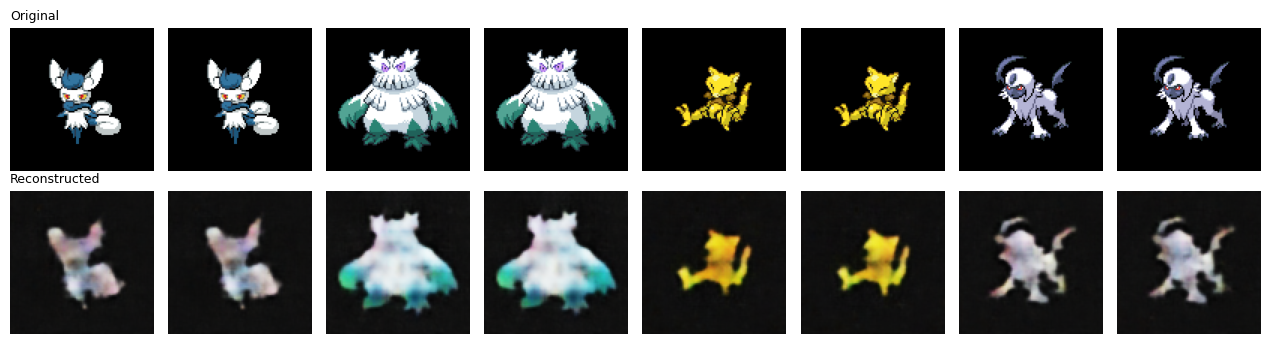

In [ ]:
@torch.no_grad()
def show_reconstructions(model, loader, device, n=8):
    model.eval()
    batch = next(iter(loader))[:n].to(device)
    recon, _, _ = model(batch)

    fig, axes = plt.subplots(2, n, figsize=(n * 1.6, 3.5))
    for i in range(n):

        orig = batch[i].cpu().permute(1, 2, 0).numpy()
        rec  = recon[i].cpu().permute(1, 2, 0).numpy()
        axes[0, i].imshow(orig[:, :, :3])
        axes[0, i].axis("off")
        axes[1, i].imshow(rec[:, :, :3])
        axes[1, i].axis("off")


    axes[0, 0].set_title("Original",      fontsize=9, loc="left")
    axes[1, 0].set_title("Reconstructed", fontsize=9, loc="left")
    plt.tight_layout()
    plt.show()

show_reconstructions(model, test_loader, device)

In [ ]:
def get_latent_vector(model, image_path, device):
    model.eval() # Set model to evaluation mode
    transform = get_transforms(cfg.image_size, augment=False)

    # Load and transform the image
    img = Image.open(image_path).convert("RGBA")
    img_tensor = transform(img).unsqueeze(0).to(device) # Add batch dimension and move to device

    with torch.no_grad():
        mu, log_var = model.encoder(img_tensor)

    return mu, log_var

In [ ]:
import json

directory = "/content/drive/MyDrive/gen_ai_image_project/pokemon_sprites/"
lat_dist_dict = {}
for i in range(1, 1026):
    match = next((f for f in os.listdir(directory) if f.startswith(f"{i}_")), None)
    if i == 696:
      print("skip tyrunt sdge :(")
      continue
    if match:
        filepath = os.path.join(directory, match)
        mu, logvar = get_latent_vector(model, filepath, device)
        lat_dist_dict[i] = {'mean': mu.cpu().numpy().tolist()[0], 'log_var':logvar.cpu().numpy().tolist()[0]}
        print("Saved distrbution for " + match)
with open("/content/drive/MyDrive/gen_ai_image_project/pokemon_distributions.json", 'w') as f:
  json.dump(lat_dist_dict, f)



Saved distrbution for 1_bulbasaur.png
Saved distrbution for 2_ivysaur.png
Saved distrbution for 3_venusaur.png
Saved distrbution for 4_charmander.png
Saved distrbution for 5_charmeleon.png
Saved distrbution for 6_charizard.png
Saved distrbution for 7_squirtle.png
Saved distrbution for 8_wartortle.png
Saved distrbution for 9_blastoise.png
Saved distrbution for 10_caterpie.png
Saved distrbution for 11_metapod.png
Saved distrbution for 12_butterfree.png
Saved distrbution for 13_weedle.png
Saved distrbution for 14_kakuna.png
Saved distrbution for 15_beedrill.png
Saved distrbution for 16_pidgey.png
Saved distrbution for 17_pidgeotto.png
Saved distrbution for 18_pidgeot.png
Saved distrbution for 19_rattata.png
Saved distrbution for 20_raticate.png
Saved distrbution for 21_spearow.png
Saved distrbution for 22_fearow.png
Saved distrbution for 23_ekans.png
Saved distrbution for 24_arbok.png
Saved distrbution for 25_pikachu.png
Saved distrbution for 26_raichu.png
Saved distrbution for 27_sandshr

## Loss Curve

In [ ]:
epochs_log, train_losses, val_losses, lrs = [], [], [], []
with open(log_path) as f:
    for row in csv.DictReader(f):
        epochs_log.append(int(row["epoch"]))
        train_losses.append(float(row["train_loss"]))
        val_losses.append(float(row["val_loss"]))
        lrs.append(float(row["lr"]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_log, train_losses, label="Train")
ax1.plot(epochs_log, val_losses,   label="Validation")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("VAE Training Loss")
ax1.legend()

ax2.plot(epochs_log, lrs, color="orange")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Learning Rate")
ax2.set_title("Learning Rate Schedule")
ax2.set_yscale("log")

plt.tight_layout()
plt.show()

In [ ]:
import torch
import math
import matplotlib.pyplot as plt
import numpy as np

# Function 1: Spherical Linear Interpolation
def slerp_latent_vector(index1, index2, alpha, device, lat_dist_dict):
    """
    Performs spherical linear interpolation (slerp) between the mean latent vectors
    of two images identified by their indices.

    Args:
        index1 (int): Index of the first image.
        index2 (int): Index of the second image.
        alpha (float): Interpolation factor between 0.0 and 1.0.
                       0.0 returns latent vector of index1, 1.0 returns latent vector of index2.
        device (torch.device): The device (cuda or cpu) for tensors.
        lat_dist_dict (dict): Dictionary containing 'mean' and 'log_var' for each image index.

    Returns:
        torch.Tensor: The interpolated latent vector.
    """
    if index1 not in lat_dist_dict or index2 not in lat_dist_dict:
        raise ValueError("One or both image indices not found in lat_dist_dict.")

    # Get mean latent vectors (mu) for both images
    mu1 = torch.tensor(lat_dist_dict[index1]['mean'], dtype=torch.float32).to(device)
    mu2 = torch.tensor(lat_dist_dict[index2]['mean'], dtype=torch.float32).to(device)

    # Handle alpha edge cases directly
    if alpha <= 0:
        return mu1
    if alpha >= 1:
        return mu2

    # Normalize vectors
    v0 = mu1 / torch.norm(mu1)
    v1 = mu2 / torch.norm(mu2)

    # Compute angle between vectors
    dot_product = torch.dot(v0, v1).clamp(-1.0, 1.0) # Clamp to avoid numerical instability
    theta = math.acos(dot_product.item())

    # If angle is very small, vectors are nearly collinear, use linear interpolation
    if theta < 1e-6:
        return (1 - alpha) * mu1 + alpha * mu2

    # Perform slerp
    slerp_vector = (math.sin((1 - alpha) * theta) / math.sin(theta)) * mu1 + \
                   (math.sin(alpha * theta) / math.sin(theta)) * mu2

    return slerp_vector

# Function 2: Decode and Visualize
@torch.no_grad()
def decode_and_visualize(latent_vector, model, device):
    """
    Decodes a latent vector using the VAE decoder and visualizes the resulting image.

    Args:
        latent_vector (torch.Tensor): The latent vector to decode.
        model (nn.Module): The VAE model.
        device (torch.device): The device (cuda or cpu) for tensors.
    """
    model.eval() # Set model to evaluation mode

    # Ensure latent_vector is on the correct device and has a batch dimension
    latent_vector = latent_vector.to(device).unsqueeze(0)

    # Decode the latent vector
    decoded_image = model.decoder(latent_vector)

    # Convert to numpy and prepare for plotting
    img = decoded_image.squeeze(0).cpu().permute(1, 2, 0).numpy()

    # Plot the image
    plt.figure(figsize=(4,4)) # Create a figure for the image
    plt.imshow(img[:, :, :3]) # Assuming RGBA, plot RGB channels
    plt.axis('off')
    plt.title("Decoded Image")
    plt.show()

In [ ]:
# Function 3: Linear Interpolation
def linear_interpolate_latent_vector(index1, index2, alpha, device, lat_dist_dict):
    """
    Performs linear interpolation between the mean latent vectors
    of two images identified by their indices.

    Args:
        index1 (int): Index of the first image.
        index2 (int): Index of the second image.
        alpha (float): Interpolation factor between 0.0 and 1.0.
                       0.0 returns latent vector of index1, 1.0 returns latent vector of index2.
        device (torch.device): The device (cuda or cpu) for tensors.
        lat_dist_dict (dict): Dictionary containing 'mean' and 'log_var' for each image index.

    Returns:
        torch.Tensor: The interpolated latent vector.
    """
    if index1 not in lat_dist_dict or index2 not in lat_dist_dict:
        raise ValueError("One or both image indices not found in lat_dist_dict.")

    # Get mean latent vectors (mu) for both images
    mu1 = torch.tensor(lat_dist_dict[index1]['mean'], dtype=torch.float32).to(device)
    mu2 = torch.tensor(lat_dist_dict[index2]['mean'], dtype=torch.float32).to(device)

    # Perform linear interpolation
    interpolated_vector = (1 - alpha) * mu1 + alpha * mu2

    return interpolated_vector

In [ ]:
poke_1 = 600
poke_2 = 30
alpha = .5

In [ ]:
latent_vector_slerp = slerp_latent_vector(poke_1, poke_2, alpha, device, lat_dist_dict)
latent_vector = linear_interpolate_latent_vector(poke_1, poke_2, alpha, device, lat_dist_dict)

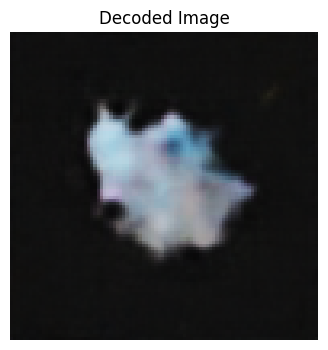

In [ ]:
decode_and_visualize(latent_vector_slerp, model, device)

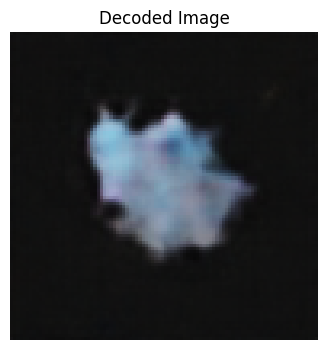

In [ ]:
decode_and_visualize(latent_vector, model, device)